<a href="https://colab.research.google.com/github/sashidharreddy33-commits/Deep-Learning/blob/main/DL_TASK5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any train

Epoch 1/10 | D Loss: 0.6438465118408203 | G Loss: 0.557920515537262
Epoch 2/10 | D Loss: 0.7168957591056824 | G Loss: 0.5131471157073975
Epoch 3/10 | D Loss: 0.7576594352722168 | G Loss: 0.4718761742115021
Epoch 4/10 | D Loss: 0.784757137298584 | G Loss: 0.43606290221214294
Epoch 5/10 | D Loss: 0.8247727751731873 | G Loss: 0.40379175543785095
Epoch 6/10 | D Loss: 0.8638944029808044 | G Loss: 0.3768942654132843
Epoch 7/10 | D Loss: 0.9029145836830139 | G Loss: 0.35081443190574646
Epoch 8/10 | D Loss: 0.9385254979133606 | G Loss: 0.32865843176841736
Epoch 9/10 | D Loss: 0.9763805866241455 | G Loss: 0.30845907330513
Epoch 10/10 | D Loss: 1.0087100267410278 | G Loss: 0.29055118560791016


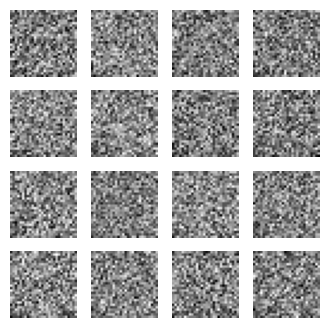

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# ===============================
# Load and preprocess MNIST dataset
# ===============================
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')

# Normalize images to [-1,1]
train_images = (train_images - 127.5) / 127.5


# ===============================
# Generator Model
# ===============================
def build_generator():

    model = tf.keras.Sequential()

    model.add(layers.Dense(128, input_shape=(100,), use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.01))

    model.add(layers.Dense(784, activation='tanh'))
    model.add(layers.Reshape((28, 28, 1)))

    return model


# ===============================
# Discriminator Model
# ===============================
def build_discriminator():

    model = tf.keras.Sequential()

    model.add(layers.Flatten(input_shape=(28, 28, 1)))
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(alpha=0.01))
    model.add(layers.Dense(1, activation='sigmoid'))

    return model


# ===============================
# Build GAN Model
# ===============================
def build_gan(generator, discriminator):

    discriminator.trainable = False

    model = tf.keras.Sequential([generator, discriminator])

    return model


# Create models
generator = build_generator()
discriminator = build_discriminator()

gan = build_gan(generator, discriminator)


# ===============================
# Compile Models
# ===============================
discriminator.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(0.0002, 0.5)
)

gan.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(0.0002, 0.5)
)





epochs = 10
batch_size = 64

for epoch in range(epochs):


    idx = np.random.randint(0, train_images.shape[0], batch_size)
    real_images = train_images[idx]


    noise = np.random.normal(0, 1, (batch_size, 100))
    generated_images = generator.predict(noise, verbose=0)

    # Labels
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_labels = np.ones((batch_size, 1))

    g_loss = gan.train_on_batch(noise, fake_labels)

    # Print progress
    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss} | G Loss: {g_loss}")


# ===============================
# Generate Images for Visualization
# ===============================
generated_images = generator.predict(np.random.normal(0, 1, (16, 100)), verbose=0)

# Rescale images to [0,1]
generated_images = 0.5 * generated_images + 0.5

plt.figure(figsize=(4,4))

for i in range(generated_images.shape[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i,:,:,0], cmap='gray')
    plt.axis('off')

plt.show()